In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the clean data we saved
df = pd.read_csv('../data/online_retail_cleaned.csv', parse_dates=['InvoiceDate'])

print(f"Loaded {len(df):,} rows")
print(f"Date range: {df['InvoiceDate'].min().strftime('%d-%m-%Y')} to {df['InvoiceDate'].max().strftime('%d-%m-%Y')}")

Loaded 805,549 rows
Date range: 01-12-2009 to 09-12-2011


In [4]:
# RFM needs a reference date, we use 1 day after the last transaction
# This represents "today" from the dataset's perspective
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date.strftime('%d-%m-%Y')}")

# Calculate RFM metrics per customer
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('Revenue', 'sum')
).reset_index()

print(f"\nRFM table shape: {rfm.shape}")
print(f"\nSample:")
print(rfm.head())

Reference date: 10-12-2011

RFM table shape: (5878, 4)

Sample:
   Customer ID  Recency  Frequency  Monetary
0        12346      326         12  77556.46
1        12347        2          8   5633.32
2        12348       75          5   2019.40
3        12349       19          4   4428.69
4        12350      310          1    334.40


In [5]:
print("RFM Summary Statistics")
print("=" * 40)
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))

RFM Summary Statistics
       Recency  Frequency   Monetary
count  5878.00    5878.00    5878.00
mean    201.33       6.29    3018.62
std     209.34      13.01   14737.73
min       1.00       1.00       2.95
25%      26.00       1.00     348.76
50%      96.00       3.00     898.92
75%     380.00       7.00    2307.09
max     739.00     398.00  608821.65


In [6]:
# Score Recency — LOWER days = BETTER = higher score (so we reverse it)
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])

# Score Frequency — HIGHER orders = BETTER = higher score
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# Score Monetary — HIGHER spend = BETTER = higher score
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# Combine into one RFM score string e.g. "555" = best customer
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print("Scores assigned successfully!")
print(rfm[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'RFM_Score']].head(10))

Scores assigned successfully!
   Customer ID  Recency  Frequency  Monetary RFM_Score
0        12346      326         12  77556.46       255
1        12347        2          8   5633.32       545
2        12348       75          5   2019.40       344
3        12349       19          4   4428.69       535
4        12350      310          1    334.40       212
5        12351      375          1    300.93       212
6        12352       36         10   2849.84       454
7        12353      204          2    406.76       222
8        12354      232          1   1079.40       213
9        12355      214          2    947.61       223


In [9]:
def assign_segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Best Customers'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f <= 2 and m <= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Cant Lose Them'
    elif r == 1 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

# See how many customers in each segment
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Customer Count']
segment_counts['% of Customers'] = (segment_counts['Customer Count'] / len(rfm) * 100).round(1)

print(segment_counts.to_string(index=False))

            Segment  Customer Count  % of Customers
    Needs Attention            1327            22.6
     Best Customers            1300            22.1
    Loyal Customers            1134            19.3
               Lost             779            13.3
            At Risk             615            10.5
      New Customers             443             7.5
Potential Loyalists             280             4.8


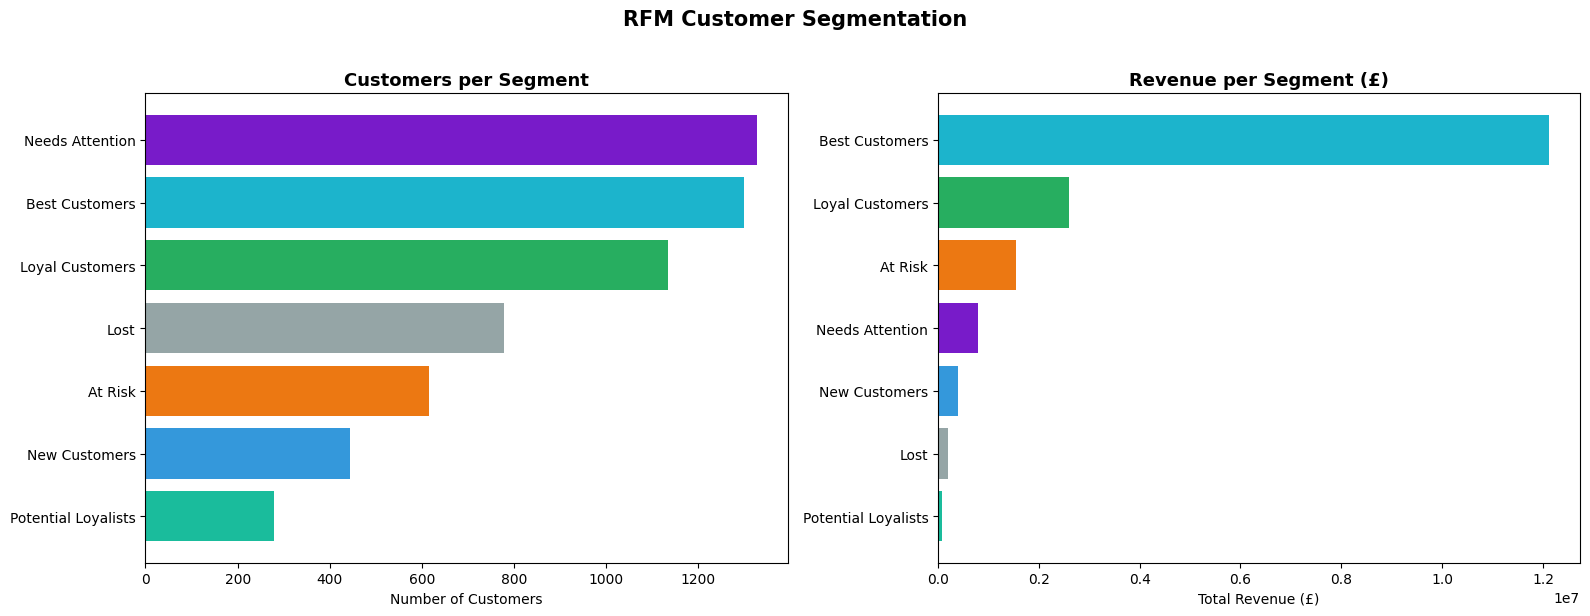


Revenue by Segment:
            Segment     Monetary  % of Revenue
     Best Customers 12128115.565          68.4
    Loyal Customers  2603183.466          14.7
            At Risk  1548098.812           8.7
    Needs Attention   796160.304           4.5
      New Customers   394638.610           2.2
               Lost   192051.121           1.1
Potential Loyalists    81181.300           0.5


In [14]:
# Define colors per segment
segment_colors = {
    'Best Customers'    : "#1cb4cc",
    'Loyal Customers'   : '#27ae60',
    'New Customers'     : '#3498db',
    'Potential Loyalists': '#1abc9c',
    'Needs Attention'   : "#781bc9",
    'At Risk'           : "#ec7812",
    'Cant Lose Them'    : '#e74c3c',
    'Lost'              : '#95a5a6'
}

colors = [segment_colors.get(s, '#bdc3c7') for s in segment_counts['Segment']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 — Customer count per segment
axes[0].barh(segment_counts['Segment'], segment_counts['Customer Count'], color=colors)
axes[0].set_title('Customers per Segment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Customers')
axes[0].invert_yaxis()

# Chart 2 — Revenue per segment
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().reset_index()
segment_revenue = segment_revenue.sort_values('Monetary', ascending=False)
rev_colors = [segment_colors.get(s, '#bdc3c7') for s in segment_revenue['Segment']]

axes[1].barh(segment_revenue['Segment'], segment_revenue['Monetary'], color=rev_colors)
axes[1].set_title('Revenue per Segment (£)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Revenue (£)')
axes[1].invert_yaxis()

plt.suptitle('RFM Customer Segmentation', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/rfm_segments.png', dpi=150)
plt.show()

# Revenue breakdown by segment
print("\nRevenue by Segment:")
segment_revenue['% of Revenue'] = (segment_revenue['Monetary']/segment_revenue['Monetary'].sum()*100).round(1)
print(segment_revenue.to_string(index=False))

In [15]:
rfm.to_csv('../data/rfm_segments.csv', index=False)
print("RFM data saved!")
print(f"Columns: {rfm.columns.tolist()}")

RFM data saved!
Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Segment']
